In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import LabelEncoder

In [2]:
df = pd.read_csv('/content/train.csv')

In [3]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [4]:
df.shape

(9800, 18)

In [5]:
df.dtypes

Row ID             int64
Order ID             str
Order Date           str
Ship Date            str
Ship Mode            str
Customer ID          str
Customer Name        str
Segment              str
Country              str
City                 str
State                str
Postal Code      float64
Region               str
Product ID           str
Category             str
Sub-Category         str
Product Name         str
Sales            float64
dtype: object

In [6]:
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

In [7]:
# Convert date columns
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True, errors='coerce')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True, errors='coerce')

In [8]:
# Create temporal features
df['Order_Month'] = df['Order Date'].dt.month
df['Order_Year'] = df['Order Date'].dt.year
df['Ship_Days'] = (df['Ship Date'] - df['Order Date']).dt.days

In [9]:
# Replace negative Ship_Days with NaN and fill missing values with median
df.loc[df['Ship_Days'] < 0, 'Ship_Days'] = np.nan
df['Ship_Days'] = df['Ship_Days'].fillna(df['Ship_Days'].median())

In [10]:
df.isna().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Order_Month       0
Order_Year        0
Ship_Days         0
dtype: int64

In [11]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Order_Month,Order_Year,Ship_Days
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,11,2017,3.0
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,11,2017,3.0
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,6,2017,4.0
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,10,2016,7.0
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,10,2016,7.0


<Axes: >

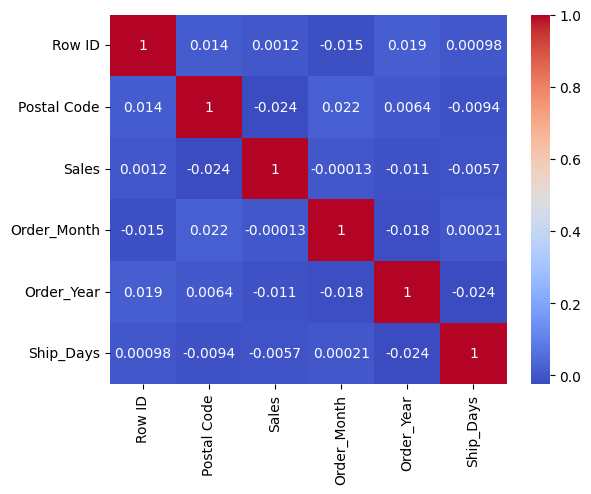

In [12]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')

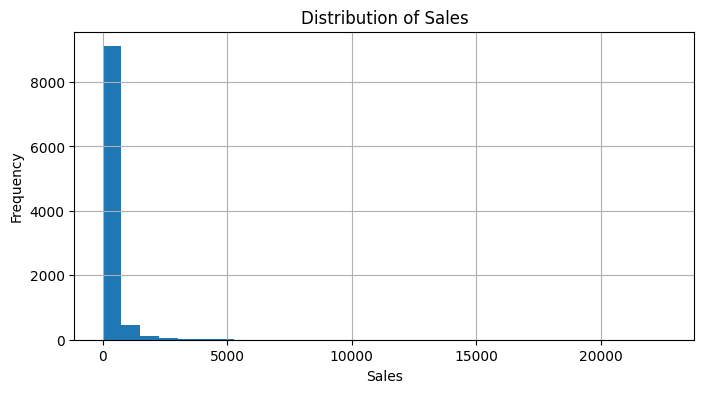

In [13]:
# Distribution of Sales
plt.figure(figsize=(8,4))
df['Sales'].hist(bins=30)
plt.title('Distribution of Sales')
plt.xlabel('Sales')
plt.ylabel('Frequency')
plt.show()

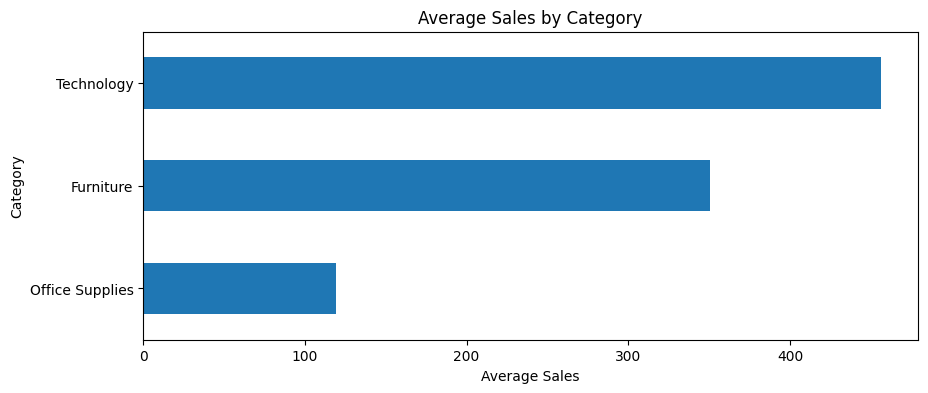

In [14]:
# Average Sales by Category
plt.figure(figsize=(10,4))
category_sales = df.groupby('Category')['Sales'].mean().sort_values()
category_sales.plot(kind='barh')
plt.title('Average Sales by Category')
plt.xlabel('Average Sales')
plt.ylabel('Category')
plt.show()

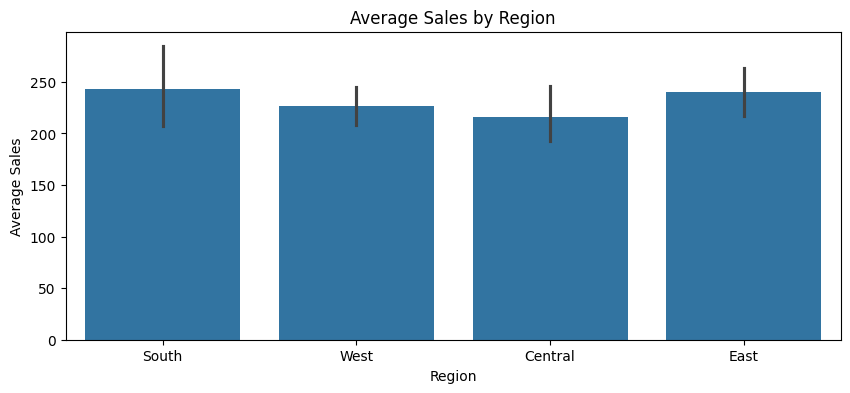

In [15]:
# Average Sales by Region
plt.figure(figsize=(10,4))
sns.barplot(x='Region', y='Sales', data=df)
plt.title('Average Sales by Region')
plt.xlabel('Region')
plt.ylabel('Average Sales')
plt.show()

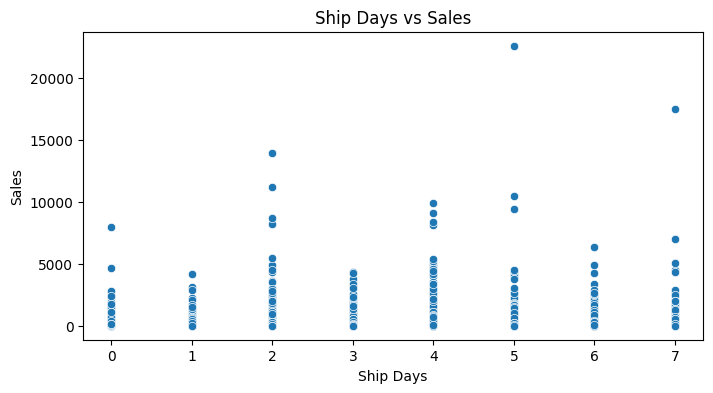

In [16]:
# Ship_Days vs Sales
plt.figure(figsize=(8,4))
sns.scatterplot(x='Ship_Days', y='Sales', data=df)
plt.title('Ship Days vs Sales')
plt.xlabel('Ship Days')
plt.ylabel('Sales')
plt.show()

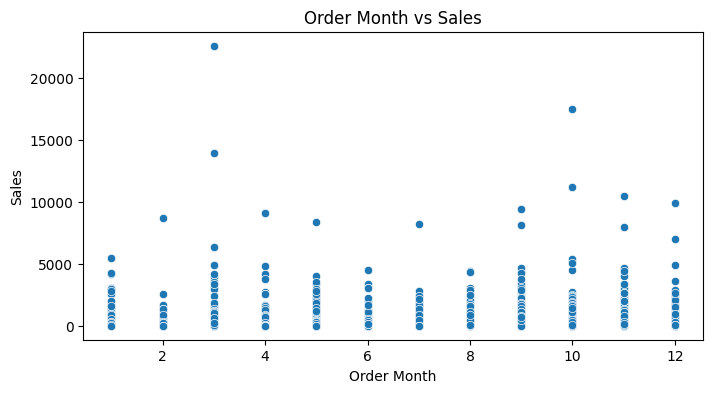

In [17]:
# Order_Month vs Sales
plt.figure(figsize=(8,4))
sns.scatterplot(x='Order_Month', y='Sales', data=df)
plt.title('Order Month vs Sales')
plt.xlabel('Order Month')
plt.ylabel('Sales')
plt.show()

In [18]:
# Drop irrelevant columns
drop_cols = [
    'Row ID', 'Order ID', 'Customer ID', 'Customer Name',
    'Product ID', 'Product Name', 'Order Date', 'Ship Date',
    'Country', 'City', 'State', 'Postal Code', 'Profit'
]
df = df.drop(columns=[col for col in drop_cols if col in df.columns])

In [19]:
# Sales is the main regression target.
# High_Sales is only a classification target for Logistic Regression.
# 1 means Sales above median.
# 0 means Sales equal to or below median.
median_sales = df['Sales'].median()
df['High_Sales'] = (df['Sales'] > median_sales).astype(int)

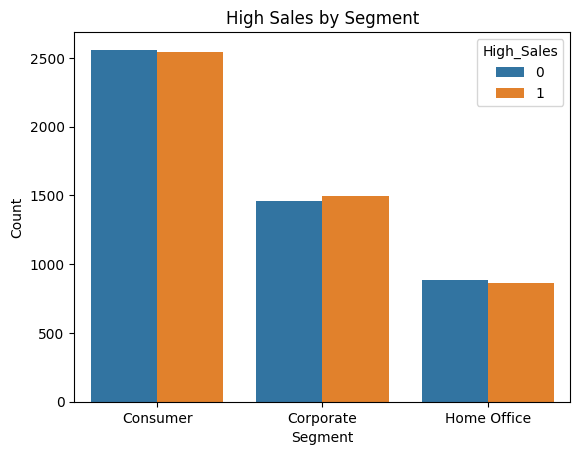

In [20]:
sns.countplot(x='Segment', hue='High_Sales', data=df)
plt.title('High Sales by Segment')
plt.xlabel('Segment')
plt.ylabel('Count')
plt.show()

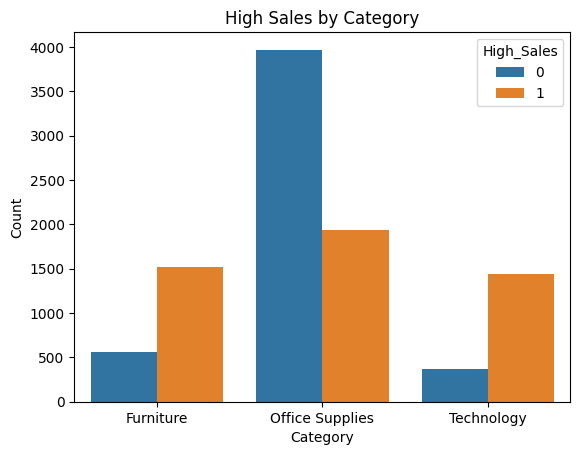

In [21]:
sns.countplot(x='Category', hue='High_Sales', data=df)
plt.title('High Sales by Category')
plt.xlabel('Category')
plt.ylabel('Count')
plt.show()

In [22]:
# Linear Regression uses one-hot encoding (pd.get_dummies)
# because it treats numbers as ordered values,
# so LabelEncoder is inappropriate for unordered categories.
df_lr = df.copy()
y_reg = df_lr['Sales']
X_reg = df_lr.drop(columns=['Sales', 'High_Sales'])
X_reg = pd.get_dummies(X_reg, drop_first=True)

In [23]:
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

In [24]:
lr_model = LinearRegression()
lr_model.fit(X_train_reg, y_train_reg)
lr_pred = lr_model.predict(X_test_reg)

In [25]:
print("Linear Regression R2 Score:", lr_model.score(X_test_reg, y_test_reg))

Linear Regression R2 Score: 0.17851770141453271


In [26]:
mae = np.mean(abs(y_test_reg - lr_pred))
rmse = np.sqrt(np.mean((y_test_reg - lr_pred) ** 2))
print("MAE:", mae)
print("RMSE:", rmse)

MAE: 238.7619814942285
RMSE: 740.9983843483507


In [27]:
df_log = df.copy()

categorical_cols = df_log.select_dtypes(include=['object']).columns

label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df_log[col] = le.fit_transform(df_log[col].astype(str))
    label_encoders[col] = le

/tmp/ipykernel_4157/3830609928.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df_log.select_dtypes(include=['object']).columns


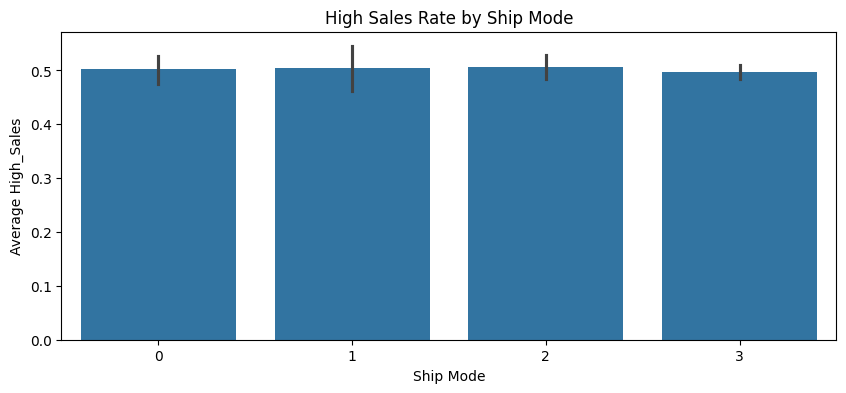

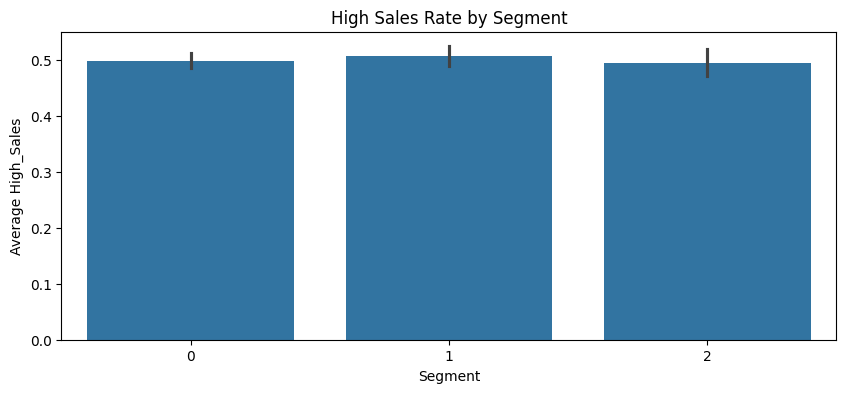

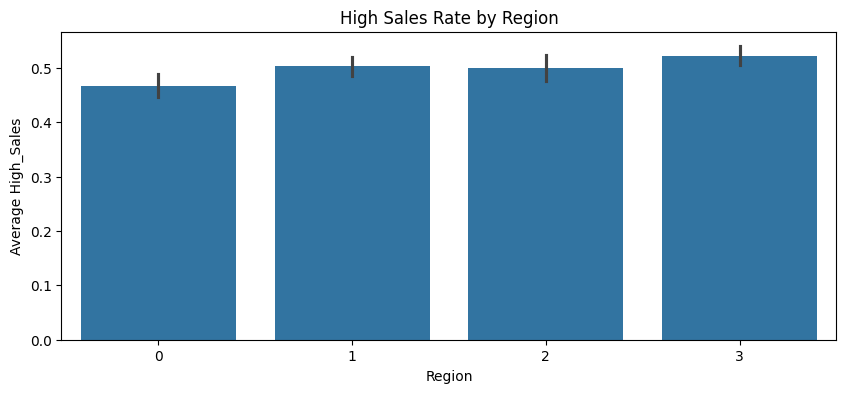

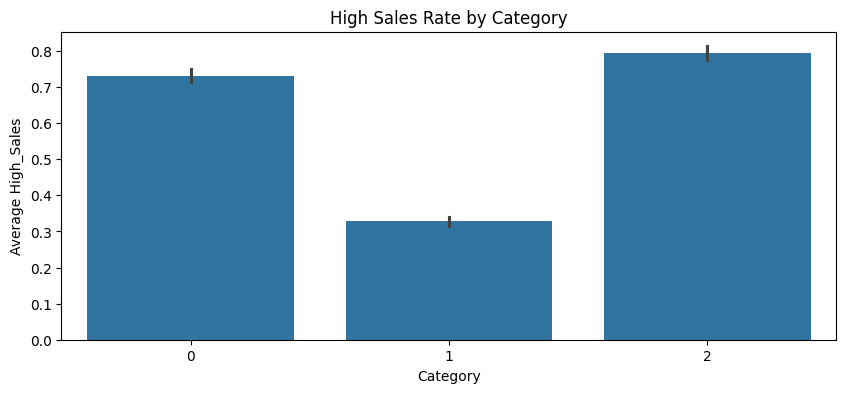

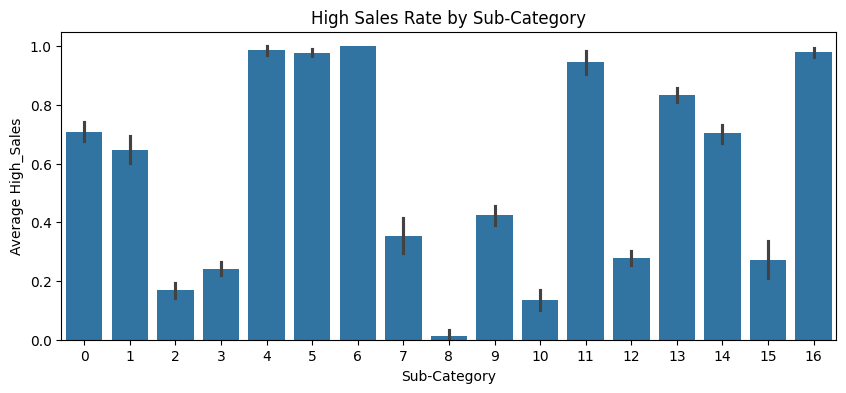

In [28]:
for col in categorical_cols:
    plt.figure(figsize=(10,4))
    sns.barplot(x=col, y='High_Sales', data=df_log)
    plt.title('High Sales Rate by ' + col)
    plt.xlabel(col)
    plt.ylabel('Average High_Sales')
    plt.show()

In [29]:
X_le = df_log.drop(columns=['Sales', 'High_Sales'])
y_clf_le = df_log['High_Sales']

In [30]:
X_train_le, X_test_le, y_train_le, y_test_le = train_test_split(
    X_le, y_clf_le, test_size=0.2, random_state=42
)

In [31]:
log_model_le = LogisticRegression(max_iter=1000)
log_model_le.fit(X_train_le, y_train_le)
log_pred_le = log_model_le.predict(X_test_le)

In [32]:
print("Logistic Regression Accuracy:", log_model_le.score(X_test_le, y_test_le))

Logistic Regression Accuracy: 0.5382653061224489


In [33]:
manual_accuracy = np.mean(y_test_le.values == log_pred_le)
print("Manual Accuracy:", manual_accuracy)

Manual Accuracy: 0.5382653061224489


In [34]:
pd.crosstab(
    y_test_le,
    log_pred_le,
    rownames=['Actual'],
    colnames=['Predicted']
)

Predicted,0,1
Actual,,
0,562,409
1,496,493


In [35]:
combined_prediction = pd.DataFrame({
    'Actual Sales': y_test_reg.values,
    'Predicted Sales': lr_pred,
    'Actual High_Sales': y_test_le.values,
    'Predicted High_Sales': log_pred_le
})

combined_prediction.head(10)

,Actual Sales,Predicted Sales,Actual High_Sales,Predicted High_Sales
0,47.940,94.379507,0,1
1,11.360,67.501422,0,1
2,10.950,331.494391,0,1
3,17.480,220.754950,0,0
4,21.120,56.780172,0,1
5,88.832,212.709486,1,0
6,6.672,143.689687,0,0
7,22.480,33.908239,0,1
8,251.580,73.684427,1,0
9,38.256,33.678188,0,0
